# ECG heartbeat classification — exploratory data analysis

**Problem:** Given one preprocessed electrocardiogram (ECG) heartbeat, predict its grouped beat label: **N, S, V, F, or Q**. The unit of analysis is **one beat row**, not a patient or an entire recording. For the clinical meaning of each label and how beats were extracted, read [ECG heartbeat classification: concepts](ecg_hb_clf.ipynb) first.

## What we will learn from the data

1. Do the CSV files have the expected shape and valid values?
2. How many beats belong to each label?
3. What do individual waveforms look like within and across labels?
4. How much do waveforms vary, and where might zero padding appear?
5. Are there possible duplicate waveforms or differences between the supplied train and test files?

**Scope:** This notebook contains exploratory data analysis (EDA) only. We use the **training file** to learn about the data. We inspect the supplied test file only for basic integrity and distribution checks; we will not choose a model based on test results. The CSVs do not include patient IDs, so they cannot establish patient-separated evaluation. These preprocessed beats are useful for an educational benchmark, not evidence of clinical readiness.

**Setup:** Python with NumPy, pandas, and matplotlib. No downloads, GPU, or generated files are required. The local `mitbih_train.csv` (about 393 MiB) and `mitbih_test.csv` (about 98 MiB) are read into memory; allow roughly a few hundred MiB of RAM for the analysis. Running the notebook does not change either CSV.

## Load the MIT-BIH beat files

The files are in `../data/ecg_hb_clf/` when Jupyter starts in this notebook's folder. The second path below also works when Jupyter starts at the repository root. Each CSV has **187 signal columns** (`0`–`186`) and **one label column** (`187`). We load values as `float32` to reduce memory use, then check the labels before converting them to integers. The separate PTB files are outside this five-class task. [Dataset description](https://www.kaggle.com/datasets/shayanfazeli/heartbeat)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_CANDIDATES = [
    Path("../data/ecg_hb_clf"),
    Path("module2/lectures/data/ecg_hb_clf"),
]
DATA_DIR = next(
    (path for path in DATA_CANDIDATES if (path / "mitbih_train.csv").is_file()
     and (path / "mitbih_test.csv").is_file()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Place mitbih_train.csv and mitbih_test.csv in module2/lectures/data/ecg_hb_clf/."
    )

N_SIGNAL = 187
SIGNAL_COLS = list(range(N_SIGNAL))
LABEL_COL = N_SIGNAL
CLASS_NAMES = {0: "N", 1: "S", 2: "V", 3: "F", 4: "Q"}
CLASS_IDS = list(CLASS_NAMES)
SEED = 42

df_train = pd.read_csv(DATA_DIR / "mitbih_train.csv", header=None, dtype=np.float32)
df_test = pd.read_csv(DATA_DIR / "mitbih_test.csv", header=None, dtype=np.float32)
print(f"Data directory: {DATA_DIR}")
print(f"Training beats: {len(df_train):,}; test beats: {len(df_test):,}")

Data directory: ../data/ecg_hb_clf
Training beats: 87,554; test beats: 21,892


## 1. Check the table structure and values

First establish what **one row** means. The dataset has no header row: columns `0`–`186` are ordered signal positions, while column `187` is the reference label. The signal positions are **not separate patients or independent features measured at different visits**; together they form one waveform.

The following checks look for missing or non-finite values, unexpected labels, and constant waveforms. A constant row would contain no visible waveform; it deserves inspection before modeling.

In [2]:
def inspect_file(df, name):
    if df.shape[1] != N_SIGNAL + 1:
        raise ValueError(f"{name} has {df.shape[1]} columns; expected 188")
    signal = df[SIGNAL_COLS].to_numpy(copy=False)
    raw_labels = df[LABEL_COL].to_numpy(copy=False)
    finite_labels = np.isfinite(raw_labels)
    valid_labels = finite_labels & np.isin(raw_labels, CLASS_IDS)
    return {
        "file": name,
        "beat_rows": len(df),
        "columns": df.shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "nonfinite_signal_cells": int((~np.isfinite(signal)).sum()),
        "invalid_label_rows": int((~valid_labels).sum()),
        "constant_signal_rows": int(np.sum(np.ptp(signal, axis=1) == 0)),
        "min_signal": float(np.nanmin(signal)),
        "max_signal": float(np.nanmax(signal)),
    }

quality = pd.DataFrame([
    inspect_file(df_train, "train"),
    inspect_file(df_test, "test"),
])
display(quality)

if quality["invalid_label_rows"].sum() or quality["nonfinite_signal_cells"].sum():
    raise ValueError("Unexpected labels or non-finite signal values: inspect the quality table.")

X_train = df_train[SIGNAL_COLS].to_numpy(copy=False)
X_test = df_test[SIGNAL_COLS].to_numpy(copy=False)
y_train = df_train[LABEL_COL].to_numpy(dtype=np.int8)
y_test = df_test[LABEL_COL].to_numpy(dtype=np.int8)
print("One model input shape:", X_train[0].shape)
print("First training label:", int(y_train[0]), CLASS_NAMES[int(y_train[0])])

,file,beat_rows,columns,missing_cells,nonfinite_signal_cells,invalid_label_rows,constant_signal_rows,min_signal,max_signal
0,train,87554,188,0,0,0,0,0.0,1.0
1,test,21892,188,0,0,0,0,0.0,1.0


One model input shape: (187,)
First training label: 0 N


**Interpretation:** `beat_rows` counts beats, not people. The minimum and maximum refer to **processed** values; they are not voltages in millivolts. If a quality count is nonzero, inspect examples rather than silently deleting rows. The data source describes cropping, resampling, and possible zero padding before release.

## 2. How balanced are the five classes?

Count beats **in each supplied file**. We use the training counts to understand what the model will learn from. A large N class can make overall accuracy look good even when a model misses rare S or F beats. The test counts are shown only as a basic description of the supplied split.

,split,label,beats,percent
0,train,N,72471,82.77
1,train,S,2223,2.54
2,train,V,5788,6.61
3,train,F,641,0.73
4,train,Q,6431,7.35
5,test,N,18118,82.76
6,test,S,556,2.54
7,test,V,1448,6.61
8,test,F,162,0.74
9,test,Q,1608,7.35


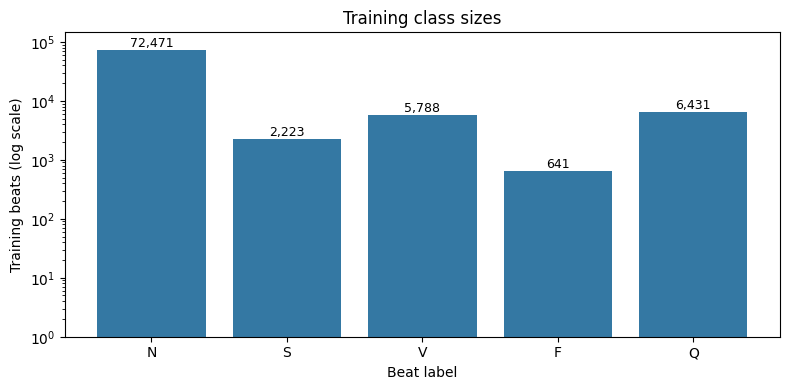

In [3]:
def class_count_table(labels, split):
    counts = pd.Series(labels).value_counts().reindex(CLASS_IDS, fill_value=0)
    return pd.DataFrame({
        "split": split,
        "label": [CLASS_NAMES[i] for i in CLASS_IDS],
        "beats": counts.to_numpy(),
        "percent": (100 * counts / counts.sum()).round(2).to_numpy(),
    })

class_counts = pd.concat([
    class_count_table(y_train, "train"),
    class_count_table(y_test, "test"),
], ignore_index=True)
display(class_counts)

train_counts = class_counts.loc[class_counts["split"] == "train", "beats"].to_numpy()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([CLASS_NAMES[i] for i in CLASS_IDS], train_counts, color="#3478a3")
ax.set(yscale="log", xlabel="Beat label", ylabel="Training beats (log scale)",
       title="Training class sizes")
for i, count in enumerate(train_counts):
    ax.text(i, count * 1.12, f"{count:,}", ha="center", fontsize=9)
ax.set_ylim(1, max(train_counts) * 2)
plt.tight_layout()
plt.show()

**Read the chart:** the vertical axis is **logarithmic** so the small classes remain visible. Compare the exact counts in the table. The class percentages describe this collection of extracted beats, **not** how often these beat types occur in a general population. The model evaluation will need per-class recall, precision, and macro F1 in addition to accuracy.

## 3. What do individual beats look like?

Plot **three reproducibly selected training beats per class**. Looking at multiple rows avoids mistaking one unusual example for the defining shape of its label. Every panel shows the 187 supplied positions, including any padded tail. The x-axis is a **position in the prepared array**, not the time of day in the original recording.

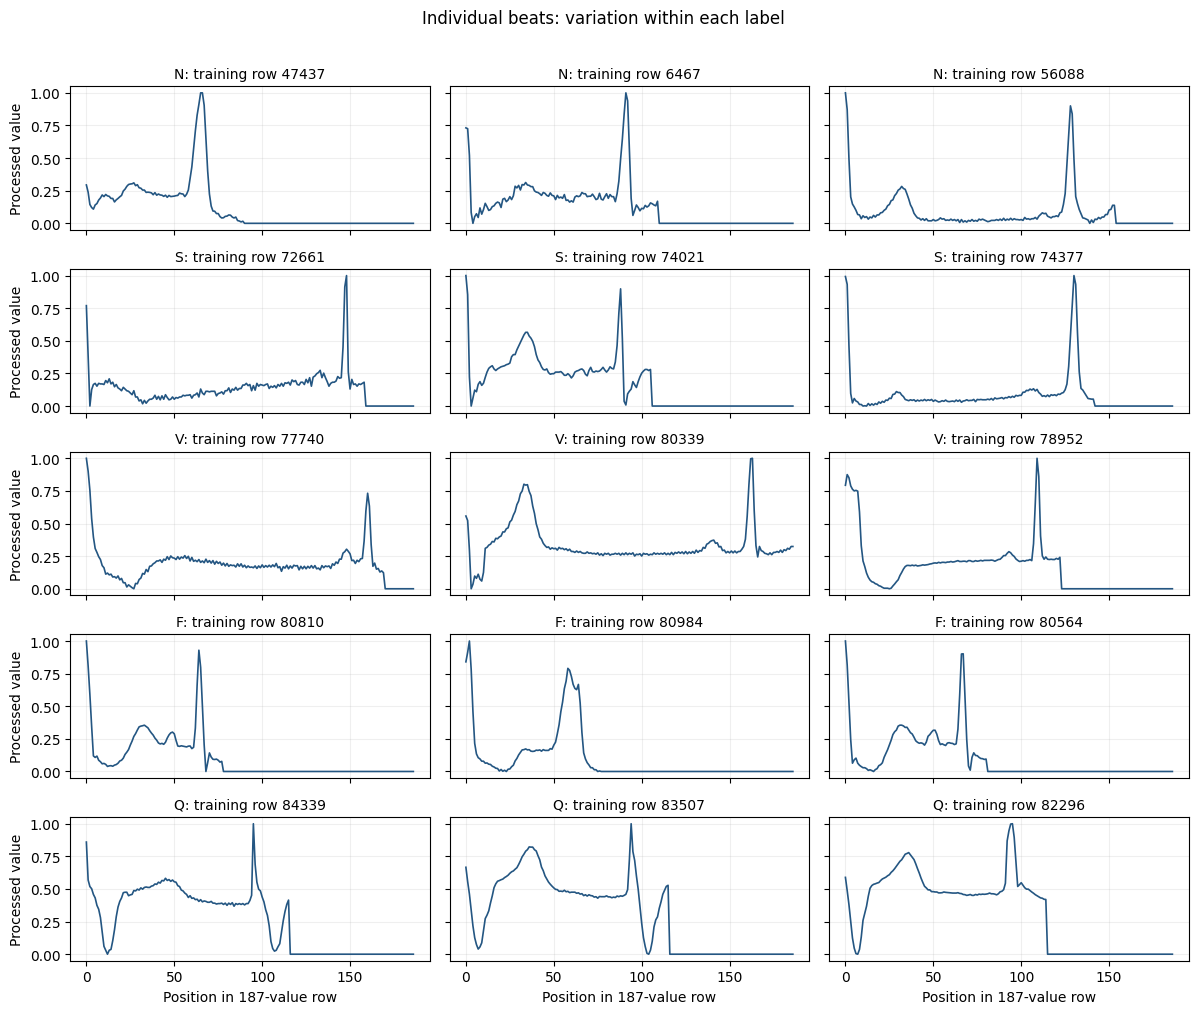

In [4]:
rng = np.random.default_rng(SEED)
EXAMPLES_PER_CLASS = 3
fig, axes = plt.subplots(5, EXAMPLES_PER_CLASS, figsize=(12, 10), sharex=True, sharey=True)
for row, label in enumerate(CLASS_IDS):
    candidates = np.flatnonzero(y_train == label)
    chosen = rng.choice(candidates, size=EXAMPLES_PER_CLASS, replace=False)
    for col, beat_idx in enumerate(chosen):
        ax = axes[row, col]
        ax.plot(np.arange(N_SIGNAL), X_train[beat_idx], color="#245682", linewidth=1.2)
        ax.set_title(f"{CLASS_NAMES[label]}: training row {beat_idx}", fontsize=10)
        ax.grid(alpha=0.2)
        if col == 0:
            ax.set_ylabel("Processed value")
        if row == len(CLASS_IDS) - 1:
            ax.set_xlabel("Position in 187-value row")
fig.suptitle("Individual beats: variation within each label", y=1.01)
plt.tight_layout()
plt.show()

**Questions to ask:** Which shapes recur within a label? How much variation is there? Where does the trace become flat? Some labels group several original beat annotations, especially **Q**, so a single waveform is not a clinical definition of its group. Visual similarity between two beats also does not prove they came from the same patient.

## 4. How much do beats vary within a class?

An average waveform alone can hide diversity. Here we draw a **median** waveform (the middle value at each position) with a shaded band from the 10th to 90th percentile. We use up to 1,000 randomly chosen **training beats per class** so this plot remains quick. The band describes variation among rows, not uncertainty in a patient's diagnosis.

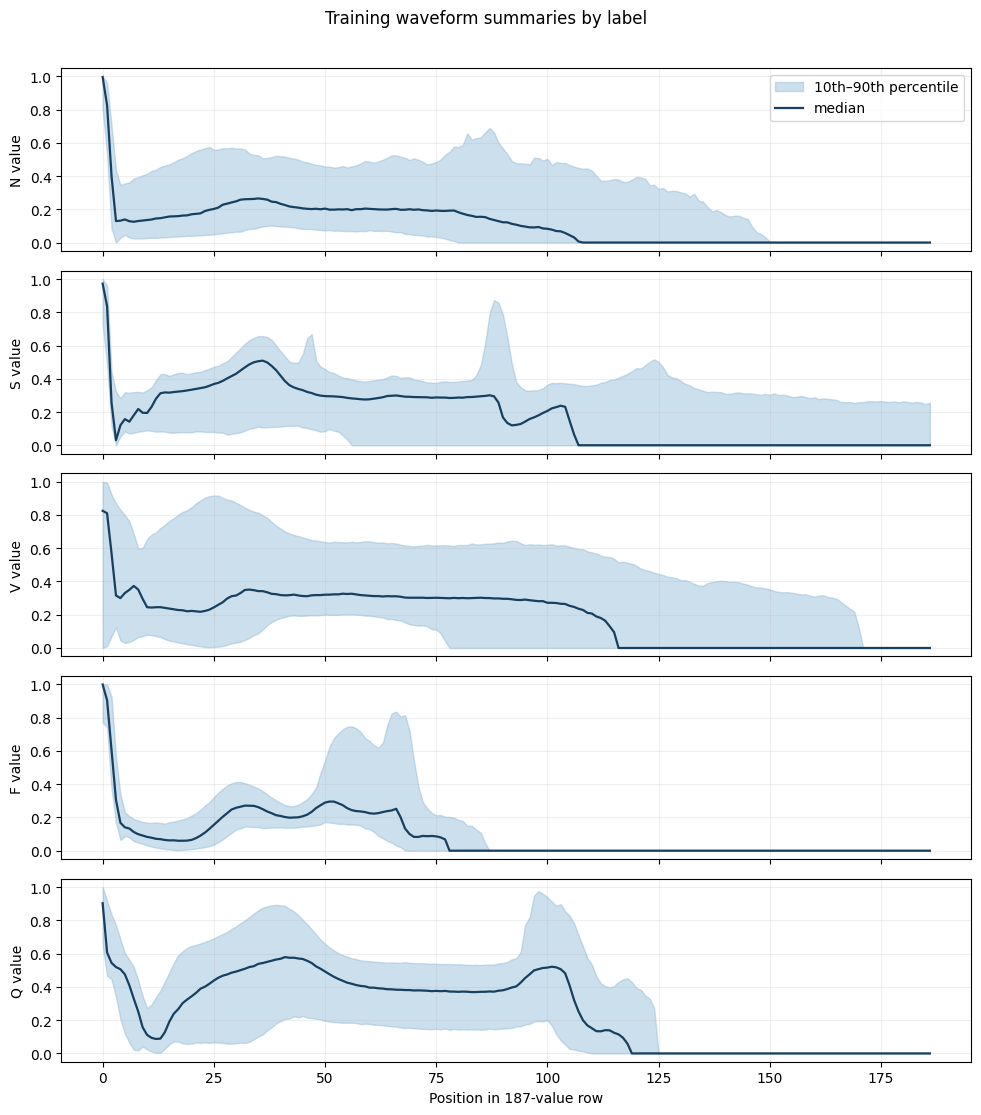

In [5]:
rng = np.random.default_rng(SEED + 1)
fig, axes = plt.subplots(5, 1, figsize=(10, 11), sharex=True, sharey=True)
for ax, label in zip(axes, CLASS_IDS):
    candidates = np.flatnonzero(y_train == label)
    chosen = rng.choice(candidates, size=min(1000, len(candidates)), replace=False)
    sample = X_train[chosen]
    low, median, high = np.percentile(sample, [10, 50, 90], axis=0)
    ax.fill_between(range(N_SIGNAL), low, high, color="#8fb9d6", alpha=0.45,
                    label="10th–90th percentile")
    ax.plot(range(N_SIGNAL), median, color="#173f5f", linewidth=1.6,
            label="median")
    ax.set_ylabel(f"{CLASS_NAMES[label]} value")
    ax.grid(alpha=0.2)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Position in 187-value row")
fig.suptitle("Training waveform summaries by label", y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** a wide band means the waveforms at that position differ across sampled beats. A flat tail can result from preprocessing. These curves summarize aligned array positions; they do **not** prove that every class has one characteristic clinical shape. Return to individual traces when a summary looks surprising.

## 5. Where might zero padding appear?

The source preprocessing pads extracted beat segments with zero values. Counting **exact zeros at the end** of each row gives a useful *padding proxy*, but it cannot perfectly recover the original cut: scaling can also produce genuine zeros. We do not remove or reinterpret these positions here.

,label,beats,median_trailing_zeros,p90_trailing_zeros
0,N,72471,81.0,108.0
1,S,2223,80.0,130.0
2,V,5788,73.0,111.0
3,F,641,109.0,118.0
4,Q,6431,67.0,74.0


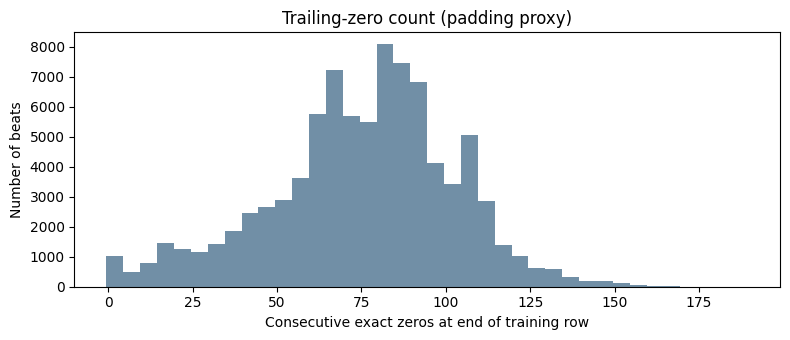

In [6]:
# Count consecutive exact zeros starting at the right edge of each training row.
nonzero_from_right = X_train[:, ::-1] != 0
trailing_zeros = np.where(
    nonzero_from_right.any(axis=1),
    np.argmax(nonzero_from_right, axis=1),
    N_SIGNAL,
)
padding_summary = pd.DataFrame({
    "label": [CLASS_NAMES[i] for i in CLASS_IDS],
    "beats": [int(np.sum(y_train == i)) for i in CLASS_IDS],
    "median_trailing_zeros": [float(np.median(trailing_zeros[y_train == i])) for i in CLASS_IDS],
    "p90_trailing_zeros": [float(np.percentile(trailing_zeros[y_train == i], 90)) for i in CLASS_IDS],
})
display(padding_summary)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(trailing_zeros, bins=np.arange(-0.5, N_SIGNAL + 5, 5), color="#718fa6")
ax.set(xlabel="Consecutive exact zeros at end of training row",
       ylabel="Number of beats", title="Trailing-zero count (padding proxy)")
plt.tight_layout()
plt.show()

**Interpretation:** `187 − trailing_zeros` is only an approximate nonzero span. Do **not** treat it as a verified clinical beat duration, because exact zeros may occur inside a normalized signal and the CSV does not provide original cut boundaries. Padding can itself become a shortcut for a model if its amount differs by class; inspect the summary above when evaluating models.

## 6. Check for repeated waveforms and split limitations

Repeated rows can distort evaluation or signal an export issue. We compute a **fingerprint** from each row's 187 signal values and count matching fingerprints within training and across the supplied train/test files. A fingerprint match is an efficient **candidate check**, not proof of identical source recordings: hashes can collide, and different beats from the same person need not be identical.

The CSVs contain **no patient or recording identifiers**, so even zero fingerprint matches would not prove a patient-separated split. A rigorous new-patient study needs the original records and annotations. [MIT-BIH database](https://physionet.org/content/mitdb/1.0.0/)

In [7]:
# Hash only the 187 signal values in each row; index=False excludes row numbers.
train_fingerprint = pd.util.hash_pandas_object(df_train[SIGNAL_COLS], index=False)
test_fingerprint = pd.util.hash_pandas_object(df_test[SIGNAL_COLS], index=False)
# A set lets us quickly check whether a test fingerprint appears in training.
train_fp_set = set(train_fingerprint.to_numpy())

# Build a one-row table of counts for possible duplication or overlap.
fingerprint_audit = pd.DataFrame([{
    # keep=False marks every training row in a repeated-fingerprint group.
    "training_rows_in_repeated_fingerprint_groups": int(train_fingerprint.duplicated(keep=False).sum()),
    # isin marks test rows whose fingerprint occurs in training.
    "test_rows_with_training_fingerprint": int(test_fingerprint.isin(train_fp_set).sum()),
    # Count fingerprint groups that have conflicting training labels.
    "training_fingerprint_groups_with_multiple_labels": int(
        # Pair each training fingerprint with its label.
        pd.DataFrame({"fp": train_fingerprint, "label": y_train})
        # For each fingerprint, count distinct labels; then count groups above one.
        .groupby("fp")["label"].nunique().gt(1).sum()
    ),
}])
display(fingerprint_audit)
print("Fingerprints flag candidates; confirm any concerning match against full rows and source records.")

,training_rows_in_repeated_fingerprint_groups,test_rows_with_training_fingerprint,training_fingerprint_groups_with_multiple_labels
0,0,0,0


Fingerprints flag candidates; confirm any concerning match against full rows and source records.


## 7. Compare the supplied split distributions

The test file is already provided. A quick class-proportion comparison can reveal a large distribution mismatch, but it cannot tell us whether the split is by patient. Keep all modeling and tuning decisions based on training/validation data, leaving test labels for final evaluation.

split,test,train
label,,
N,82.76,82.77
S,2.54,2.54
V,6.61,6.61
F,0.74,0.73
Q,7.35,7.35


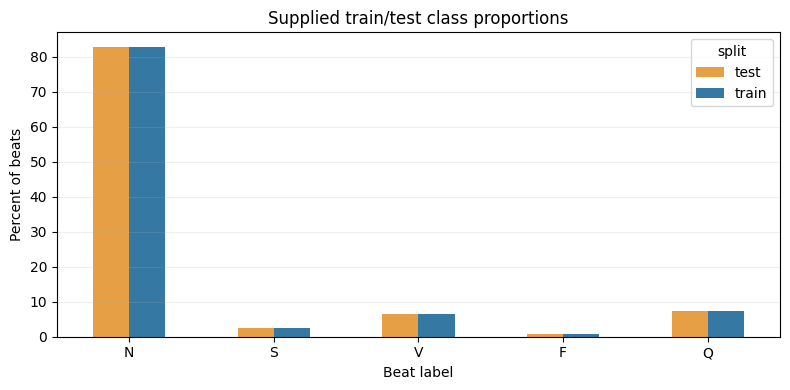

In [8]:
shares = class_counts.pivot(index="label", columns="split", values="percent")
shares = shares.reindex([CLASS_NAMES[i] for i in CLASS_IDS])
display(shares)
fig, ax = plt.subplots(figsize=(8, 4))
shares.plot.bar(ax=ax, color={"train": "#3478a3", "test": "#e69f45"})
ax.set(xlabel="Beat label", ylabel="Percent of beats",
       title="Supplied train/test class proportions")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## EDA takeaways and next step

After running the cells, write down:

1. The shape, valid label set, and any data-quality issues.
2. The rarest class and why accuracy alone would be misleading.
3. Two waveform differences or variations you saw, with the training row numbers used as examples.
4. What the trailing-zero and fingerprint checks suggest—and what they **cannot** establish.

The next part of a model notebook should define a validation split, a simple baseline, and evaluation metrics before training a complex model. These CSVs can benchmark **beat classification**; they do not establish clinical performance on new patients.

**Sources:** [Kaggle dataset card](https://www.kaggle.com/datasets/shayanfazeli/heartbeat) · [source paper](https://arxiv.org/pdf/1805.00794) · [original MIT-BIH database](https://physionet.org/content/mitdb/1.0.0/).